# Outlier Handling and KDE Analysis

This notebook performs outlier diagnostics separately from preprocessing, and produces outlier QA artifacts.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def resolve_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory")

ROOT = resolve_repo_root(Path.cwd())
INPUT_PATH = ROOT / "data" / "interim" / "ILPD_cleaned.csv"
REPORTS_DIR = ROOT / "produced_reports" / "docs"
FIGURES_DIR = ROOT / "produced_reports" / "figures" / "eda" / "outliers"

for directory in [REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Input: {INPUT_PATH}")
print(f"Reports: {REPORTS_DIR}")
print(f"Figures: {FIGURES_DIR}")

Input: /Users/samyabrataroy/Downloads/Spring_Internship_2026/data/interim/ILPD_cleaned.csv
Reports: /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/docs
Figures: /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/figures/eda/outliers


## 1) Load cleaned dataset

In [3]:
df = pd.read_csv(INPUT_PATH)
print(df.shape)
df.head()

(570, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Result
0,65,1,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,0,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,0,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,0,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,0,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 2) Outlier detection report (IQR, Z-score, Modified Z-score)

In [4]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["Result", "Gender"], errors="ignore")

report_rows = []
for col in num_cols:
    series = df[col]

    # IQR method
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    iqr_outliers = int(((series < iqr_lower) | (series > iqr_upper)).sum())

    # Z-score method
    std = series.std(ddof=0)
    mean = series.mean()
    if std == 0:
        z_outliers = 0
    else:
        z = ((series - mean) / std).abs()
        z_outliers = int((z > 3).sum())

    # Modified Z-score method
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        mz_outliers = 0
    else:
        modified_z = (0.6745 * (series - median) / mad).abs()
        mz_outliers = int((modified_z > 3.5).sum())

    report_rows.append({
        "feature": col,
        "rows": int(len(df)),
        "iqr_outliers": iqr_outliers,
        "iqr_pct": round(100 * iqr_outliers / len(df), 2),
        "zscore_outliers": z_outliers,
        "zscore_pct": round(100 * z_outliers / len(df), 2),
        "modified_z_outliers": mz_outliers,
        "modified_z_pct": round(100 * mz_outliers / len(df), 2),
    })

outlier_report = pd.DataFrame(report_rows).sort_values("iqr_pct", ascending=False)
outlier_report

,feature,rows,iqr_outliers,iqr_pct,zscore_outliers,zscore_pct,modified_z_outliers,modified_z_pct
1,Total_Bilirubin,570,83,14.56,17,2.98,145,25.44
2,Direct_Bilirubin,570,80,14.04,19,3.33,133,23.33
4,Alamine_Aminotransferase,570,72,12.63,10,1.75,74,12.98
3,Alkaline_Phosphotase,570,69,12.11,14,2.46,72,12.63
5,Aspartate_Aminotransferase,570,66,11.58,6,1.05,80,14.04
8,Albumin_and_Globulin_Ratio,570,10,1.75,3,0.53,9,1.58
6,Total_Proteins,570,8,1.40,3,0.53,2,0.35
0,Age,570,0,0.00,0,0.00,0,0.00
7,Albumin,570,0,0.00,0,0.00,0,0.00


## 3) Kernel Density Estimation (KDE) visuals

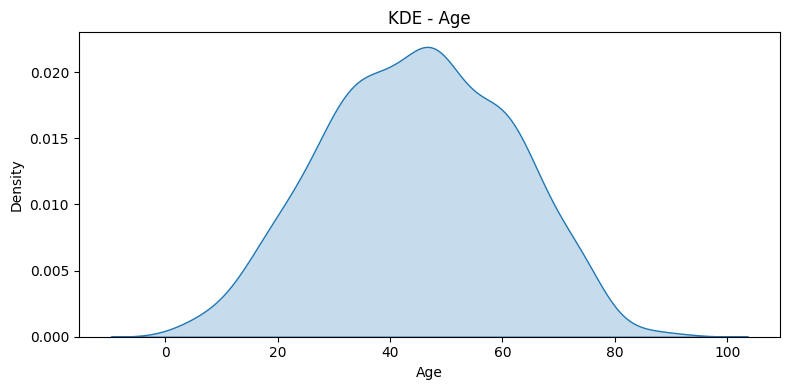

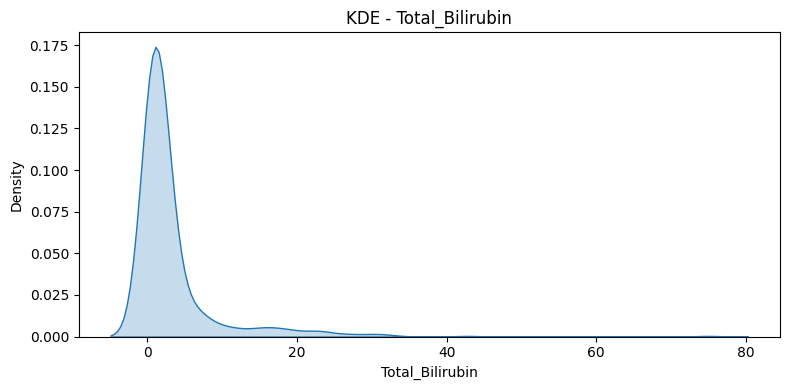

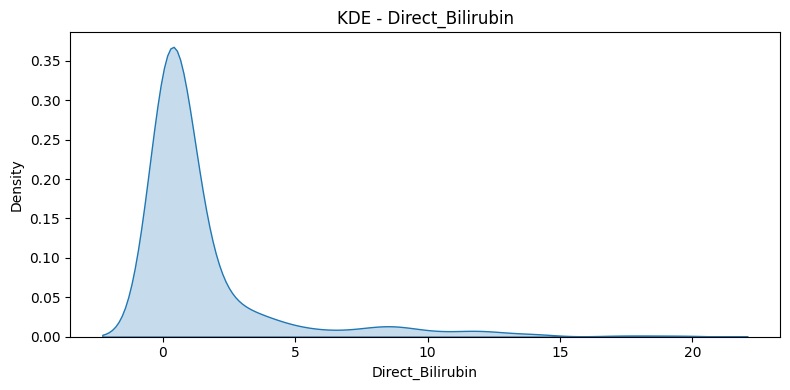

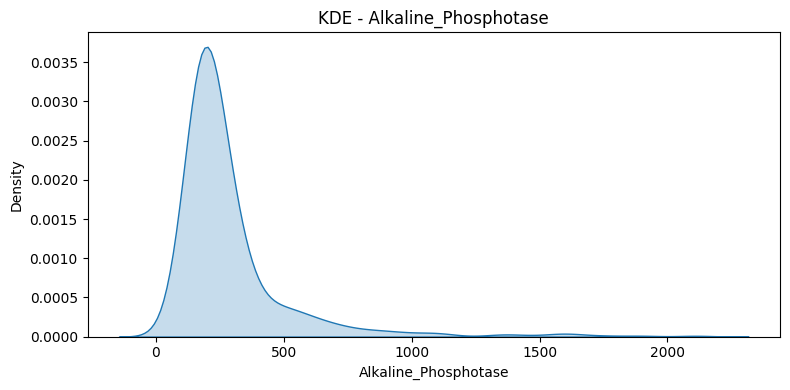

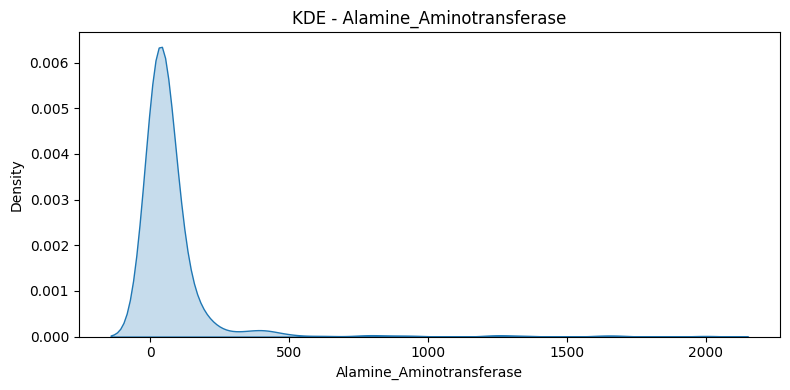

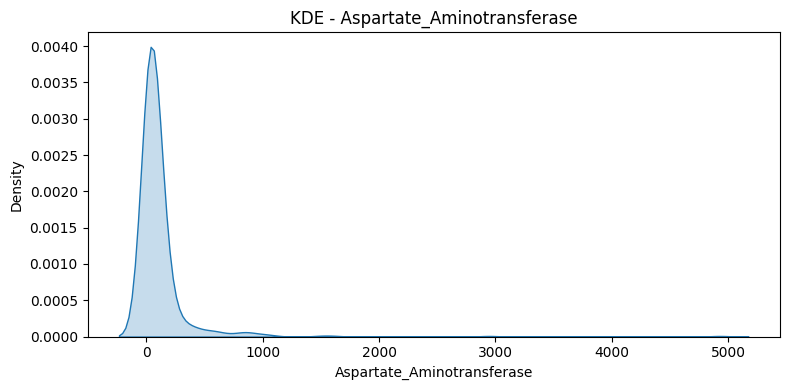

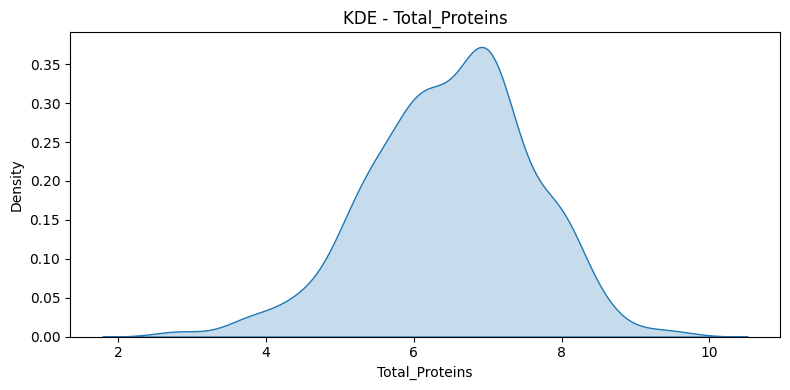

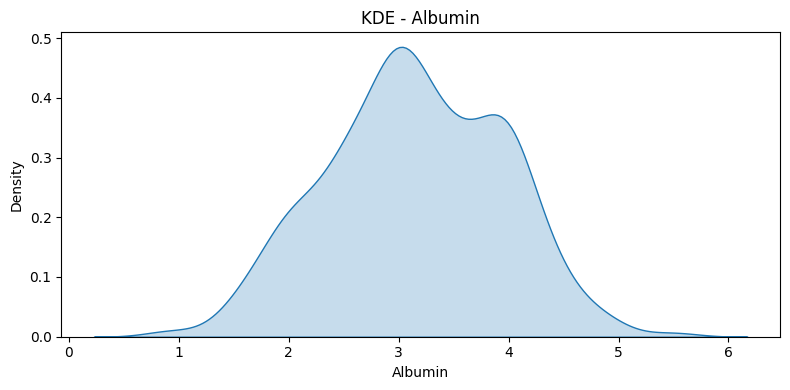

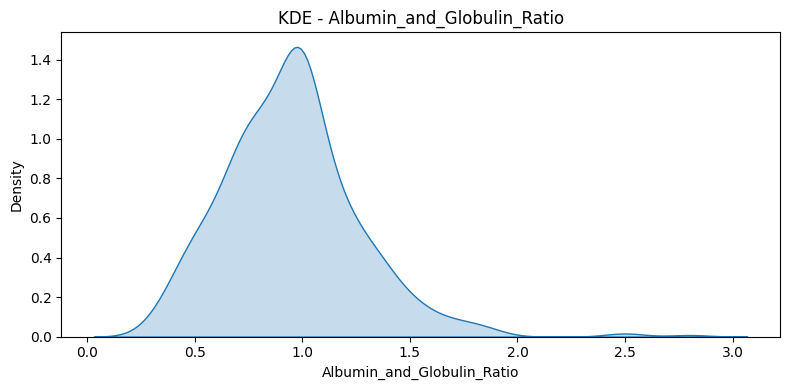

In [5]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, fill=True)
    plt.title(f"KDE - {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"kde_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

## 4) Persist outlier artifacts

In [6]:
outlier_report_path = REPORTS_DIR / "ILPD_outlier_report.csv"
outlier_report.to_csv(outlier_report_path, index=False)

print("Saved:")
print(outlier_report_path)
print(FIGURES_DIR)

Saved:
/Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/docs/ILPD_outlier_report.csv
/Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/figures/eda/outliers


## Export notebook to HTML report

In [8]:
import subprocess

HTML_DIR = ROOT / "produced_reports"
HTML_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PATH = ROOT / "scripts" / "02_outlier_handling.ipynb"

subprocess.run([
    "jupyter", "nbconvert",
    "--to", "html",
    str(NOTEBOOK_PATH),
    "--output-dir", str(HTML_DIR),
], check=True)

print(f"Exported HTML to: {HTML_DIR / NOTEBOOK_PATH.with_suffix('.html').name}")

[NbConvertApp] Converting notebook /Users/samyabrataroy/Downloads/Spring_Internship_2026/scripts/02_outlier_handling.ipynb to html


Exported HTML to: /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/02_outlier_handling.html


[NbConvertApp] Writing 294447 bytes to /Users/samyabrataroy/Downloads/Spring_Internship_2026/produced_reports/02_outlier_handling.html
